이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- numpy
- matplotlib

예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 5-3 좀 더 복잡한 이미지를 다루는 딥러닝

본 노트북은 본문 5-3절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- CIFAR-10 데이터셋으로 컬러 이미지 분류 모델 만들기
- 데이터 증강으로 과적합 줄이기
- 드롭아웃 계층 추가
- 하드웨어 가속기(GPU 등)를 사용한 학습

본문의 모델 6의 구현에 해당되며, 모델 6의 제시문은 다음과 같다.

> **모델 6. CIFAR-10 이미지 분류기**
>
> 합성곱 신경망 모델을 CIFAR-10 데이터셋으로 학습해 이미지 분류기를 만든다. CIFAR-10 데이터셋의 샘플은 10종류의 객체를 담은 32x32 크기의 3채널 컬러 이미지이다.

## 데이터 준비

- CIFAR-10은 MNIST와 달리 3채널 컬러 이미지이며, 배경과 객체의 자세가 다양해 난도가 높다.
- 채널이 셋이므로 `Normalize`의 평균과 표준편차도 채널 수만큼 지정한다.

In [3]:
######################################################################################
# 코드 5-12 - 데이터 준비 과정
######################################################################################

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 텐서 변환과 표준화 변환으로 구성된 데이터 변환 객체
# 표준화 변환의 기준 평균과 표준편차는 채널별 튜플로 지정해야 함
cifar10_mean = (0.5, 0.5, 0.5)
cifar10_std  = (0.5, 0.5, 0.5)
transform_chain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# CIFAR 내장 데이터셋으로 train_set (train=True)과 test_set 생성
train_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_chain)
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_chain)

# train_set 을 40,000개의 훈련 데이터셋과 10,000개의 검증 데이터셋으로 분리
train_set, valid_set = random_split(
    train_set, [40000, 10000],                      # 훈련 데이터셋과 검증 데이터셋의 샘플 수
    generator=torch.Generator().manual_seed(SEED),  # 난수 발생기(시드값 SEED 지정)
)

# 훈련, 검증, 평가 데이터로더 생성
BATCH_SIZE = 128                                    # 배치 크기: 2의 거듭제곱수 추천
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set)}')
print(f'검증 샘플 수: {len(valid_set)}')
print(f'평가 샘플 수: {len(test_set)}')
print(f'이미지 텐서 형태: {tuple(train_set[0][0].shape)}')   # (3, 32, 32)

훈련 샘플 수: 40000
검증 샘플 수: 10000
평가 샘플 수: 10000
이미지 텐서 형태: (3, 32, 32)


- 데이터셋에 어떤 이미지가 들어 있는지 클래스별로 확인한다([그림 5-13]).

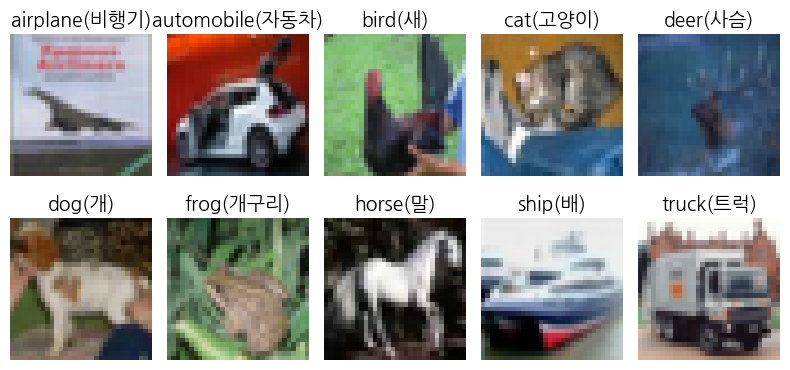

In [4]:
# 참고 - CIFAR-10 클래스별 예시 이미지([그림 5-13])

# CIFAR-10 데이터셋의 classes 속성에서 클래스별 이름을 확인할 수 있음
class_names = datasets.CIFAR10(
    root=data_root, train=False, download=False
).classes

# 한글 클래스 이름
class_names_kor = {
    'airplane': '비행기',
    'automobile': '자동차',
    'bird': '새',
    'cat': '고양이',
    'deer': '사슴',
    'dog': '개',
    'frog': '개구리',
    'horse': '말',
    'ship': '배',
    'truck': '트럭',
}

# 각 클래스의 첫 번째 샘플 이미지를 시각화
raw_test = datasets.CIFAR10(
    root=data_root, train=False,
    download=False, transform=transforms.ToTensor()
)

first_indices = {}
for idx in range(len(raw_test)):
    _, lbl = raw_test[idx]
    if lbl not in first_indices:
        first_indices[lbl] = idx
    if len(first_indices) == 10:
        break

imgs = [raw_test[first_indices[c]][0] for c in range(10)]
descs = [f'{class_names[c]}({class_names_kor[class_names[c]]})' for c in range(10)]
viz.plot_images(imgs, descs, images_per_row=5)

## 기본 모델

- 5-2절에서 만든 합성곱 블록 구조를 CIFAR-10에 맞춰 수정한다.
    - 입력 채널이 3이고, 이미지 크기가 32x32이므로 분류기의 입력 크기도 달라진다.

In [5]:
######################################################################################
# 코드 5-13 - CIFAR-10 분류 합성곱 신경망 모델
######################################################################################

import torch.nn as nn

# ConvBlock: 합성곱 계층, ReLU 활성화 계층, 최대 풀링 계층으로 구성 ([코드 5-10] 참고)
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv_block(x)


# 합성곱 신경망을 사용하는 CIFAR-10 이미지 분류기 모델 클래스
class CIFAR10ConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # 특징 추출기: 두 개의 합성곱 블록
        # 첫 번째 합성곱 블록: 5x5 필터, padding=2로 수용 영역을 빠르게 확장
        # CIFAR-10은 3채널 컬러 이미지이므로 첫 번째 블록의 입력 채널은 3
        self.conv_block_1 = ConvBlock(in_channels=3, out_channels=16,
                                      kernel_size=5, stride=1, padding=2)
        # 두 번째 합성곱 블록: 3x3 필터, padding=1
        self.conv_block_2 = ConvBlock(in_channels=16, out_channels=32,
                                      kernel_size=3, stride=1, padding=1)
        # 분류기: 완전 연결 계층(은닉층 -> 출력층으로 구성)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (B, 32, 8, 8) -> (B, 2048)
            nn.Linear(32 * 8 * 8, 256),     #               -> (B, 256)
            nn.ReLU(),
            nn.Linear(256, 10),             #               -> (B, 10)
        )

    def forward(self, x):
        x = self.conv_block_1(x)            # (B, 3, 32, 32) -> (B, 16, 16, 16)
        x = self.conv_block_2(x)            #                -> (B, 32, 8, 8)
        x = self.classifier(x)              #                -> (B, 10)
        return x


model = CIFAR10ConvClassifier()
print(model)

CIFAR10ConvClassifier(
  (conv_block_1): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block_2): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


- 학습 함수는 5-2절의 함수를 그대로 사용한다.

In [6]:
# 참고 - 학습 함수는 5-2절의 학습 함수를 그대로 사용
import copy

# 배치별 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

# 조기 종료를 적용한 학습 루프 함수
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'), target_rows=epochs)
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

In [7]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

에포크    훈련 손실    검증 손실     시간
  1/20       1.5013       1.2783     0:18


  2/20       1.1932       1.1388     0:36


  3/20       1.0451       1.0520     0:53


  4/20       0.9292       0.9786     1:11


  5/20       0.8351       0.9142     1:28


...

  8/20       0.6018       0.9330     2:22


  9/20       0.5330       0.8996     2:40


 10/20       0.4662       0.9675     2:59


 11/20       0.4018       0.9843     3:17


 12/20       0.3332       1.0338     3:33
최적(7 에포크/검증 손실 0.8828) 파라미터로 모델 복원


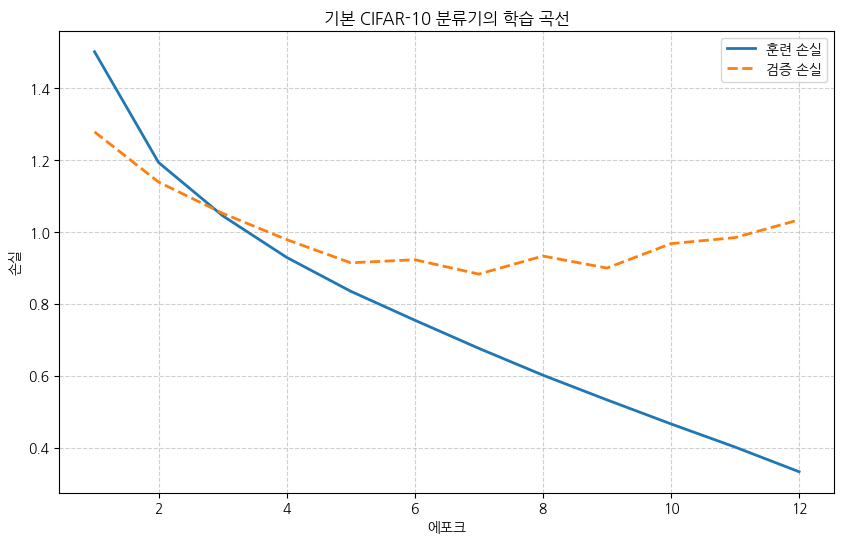

In [8]:
# 참고 - 기본 CIFAR-10 분류 합성곱 신경망 모델의 학습 결과
import torch.optim as optim

model = CIFAR10ConvClassifier()

# 학습 환경 설정
LR = 0.001
EPOCHS = 20
PATIENCE = 5
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 모델 학습
log_base = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)

# 학습 곡선 그래프
log_base.plot(title='기본 CIFAR-10 분류기의 학습 곡선', y_label='손실')

- 훈련 정확도와 평가 정확도의 차이로 과적합 정도를 확인한다.

In [9]:
# 참고 - 훈련 데이터셋과 평가 데이터셋의 분류 정확도

#train_eval_loader = DataLoader(train_set, batch_size=BATCH_SIZE)
acc_train_base, _, _ = common.get_accuracy(model, train_loader)
acc_test_base, _, _ = common.get_accuracy(model, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_base:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_base:.2f}%')

훈련 데이터셋 분류 정확도: 80.97%
평가 데이터셋 분류 정확도: 69.33%


## 데이터 증강

- 데이터 증강은 원본 데이터를 변형해 학습 데이터의 다양성을 늘리는 방법이다.
    - 모델이 특정 배치나 방향에 치우쳐 학습하는 것을 막아 과적합을 줄인다.
- 증강 변환은 **훈련 데이터셋에만** 적용한다. 검증과 평가는 원본 그대로 해야 성능을 제대로 잴 수 있다.

In [10]:
# 참고 - 모델 개선 후 훈련 데이터셋 평가를 위해 훈련 데이터로더를 평가용 훈련 데이터로더로 백업
train_eval_loader = train_loader

In [11]:
######################################################################################
# 코드 5-14 - 데이터 증강 변환을 추가한 훈련 데이터셋 전용 데이터 변환 객체
######################################################################################

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),     # 50% 확률로 좌우 반전(기본값 0.5)
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])
print(train_transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


In [12]:
######################################################################################
# 코드 5-15 - 훈련 데이터셋에만 증강 변환을 추가해 만든 데이터로더
######################################################################################

# 증강 변환을 적용한 데이터셋과 적용하지 않은 데이터셋을 각각 만든 후
#   증강 변환을 적용한 데이터셋에서는 훈련 데이터셋을 분리
#   증강 변환을 적용하지 않은 데이터셋에서는 검증 데이터셋을 분리
#   단, 훈련 데이터셋의 샘플과 검증 데이터셋의 샘플이 겹치지 않도록 같은 기준으로 무작위 분리

# 증강 변환을 포함해 훈련 데이터셋 생성
train_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)

# 증강 변환 없이 검증 데이터셋 생성
# 기존의 transform_chain(RandomHorizontalFlip 미적용) 사용
valid_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_chain)

# 동일한 SEED 로 분리해야 훈련과 검증 데이터셋의 샘플이 겹치지 않음
train_set, _ = random_split(train_set, [40000, 10000],
                            generator=torch.Generator().manual_seed(SEED))
_, valid_set = random_split(valid_set, [40000, 10000], 
                            generator=torch.Generator().manual_seed(SEED))

# 데이터로더 생성
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

# 평가 데이터로더는 기존과 동일
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'증강 훈련 샘플 수: {len(train_set)}')
print(f'증강 미적용 검증 샘플 수: {len(valid_set)}')

증강 훈련 샘플 수: 40000
증강 미적용 검증 샘플 수: 10000


In [13]:
# 참고 - 증강 변환(50% 확률 좌우 반전)을 적용한 데이터로 모델을 학습한 결과
model_aug = CIFAR10ConvClassifier()
optimizer = optim.Adam(model_aug.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 증강 변환 적용으로 인해서 조기 종료 에포크가 바뀔 수 있으므로 경우에 따라 전체 학습 에포크 수정이 필요
EPOCHS = 20

# 모델 학습
log_aug = train_with_early_stopping(
    model_aug, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)
# 증강 변환을 적용한 훈련 데이터로더로 평가하면 공정한 평가가 이루어지지 않음
#   이를 위해서 백업해둔 증강 변환이 적용되지 않은 훈련 데이터로더를 평가에 사용
acc_train_aug, _, _ = common.get_accuracy(model_aug, train_eval_loader)
acc_test_aug, _, _ = common.get_accuracy(model_aug, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_aug:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_aug:.2f}%')

에포크    훈련 손실    검증 손실     시간
  1/20       1.5278       1.3207     0:14


  2/20       1.2078       1.1056     0:28


  3/20       1.0557       1.0018     0:41


  4/20       0.9488       0.9418     0:54


  5/20       0.8687       0.9115     1:09


...

 11/20       0.5701       0.8183     2:28


 12/20       0.5297       0.8452     2:41


 13/20       0.4945       0.8459     2:55


 14/20       0.4567       0.8638     3:08
최적(9 에포크/검증 손실 0.8105) 파라미터로 모델 복원


훈련 데이터셋 분류 정확도: 80.55%
평가 데이터셋 분류 정확도: 71.79%


## 드롭아웃

- 드롭아웃은 학습 중 일부 뉴런을 무작위로 꺼서 특정 뉴런에 의존하지 않도록 만드는 기법이다.
    - 평가 모드에서는 자동으로 꺼지므로 `model.eval()` 호출을 잊지 않아야 한다.

In [14]:
######################################################################################
# 코드 5-16 - 드롭아웃 계층을 추가한 CIFAR-10 분류기 모델 클래스
######################################################################################

# 드롭아웃 계층을 추가한 CIFAR-10 이미지 분류기 모델 클래스
class CIFAR10ConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block_1 = ConvBlock(in_channels=3, out_channels=16,
                                      kernel_size=5, stride=1, padding=2)
        self.conv_block_2 = ConvBlock(in_channels=16, out_channels=32,
                                      kernel_size=3, stride=1, padding=1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),          # 50% 확률로 출력을 0으로 바꾸는 드롭아웃 계층
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_block_1(x)        # (B, 3, 32, 32) -> (B, 16, 16, 16)
        x = self.conv_block_2(x)        # (B, 16, 16, 16) -> (B, 32, 8, 8)
        x = self.classifier(x)          # (B, 32, 8, 8) -> (B, 10)
        return x


model_drop = CIFAR10ConvClassifier()
print(model_drop)

CIFAR10ConvClassifier(
  (conv_block_1): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block_2): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [15]:
# 참고 - 드롭아웃 추가 모델 학습
model_dropout = CIFAR10ConvClassifier()
optimizer = optim.Adam(model_dropout.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 드롭아웃 추가로 인해서 조기 종료 에포크가 바뀔 수 있으므로 경우에 따라 전체 학습 에포크 수정이 필요
EPOCHS = 30

# 모델 학습: 증강 변환이 적용된 훈련 데이터셋 사용
log_aug = train_with_early_stopping(
    model_dropout, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)
acc_train_dropout, _, _ = common.get_accuracy(model_dropout, train_eval_loader)
acc_test_dropout, _, _ = common.get_accuracy(model_dropout, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_dropout:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_dropout:.2f}%')

에포크    훈련 손실    검증 손실     시간
  1/30       1.6345       1.3407     0:13


  2/30       1.3335       1.1777     0:27


  3/30       1.2121       1.0882     0:40


  4/30       1.1117       1.0013     0:54


  5/30       1.0435       0.9614     1:07


...

 24/30       0.6221       0.7986     5:39


 25/30       0.6126       0.7759     5:54


 26/30       0.6035       0.7971     6:08


 27/30       0.5884       0.7895     6:23
최적(22 에포크/검증 손실 0.7723) 파라미터로 모델 복원


훈련 데이터셋 분류 정확도: 84.43%
평가 데이터셋 분류 정확도: 73.32%


## 하드웨어 가속기 사용

- 파이토치는 실행 환경에 따라 CPU, CUDA(NVIDIA GPU), MPS(Apple Silicon) 등의 장치를 사용할 수 있다.
- 모델과 텐서를 같은 장치로 옮겨야 연산이 가능하다.

In [16]:
######################################################################################
# 코드 5-17 - 실행 환경에 따라 장치 객체 생성
######################################################################################

if torch.cuda.is_available():                       # cuda 사용 조건 확인
    device = torch.device('cuda')
elif torch.backends.mps.is_available():             # mps 사용 조건 확인
    device = torch.device('mps')
else:                                               # 둘 다 사용할 수 없는 경우
    device = torch.device('cpu')

# print() 함수로 장치 객체를 출력해 확인 가능

print(f'현재의 하드웨어 가속기 장치: {device}')     # 출력 결과: mps, cuda, cpu 등

현재의 하드웨어 가속기 장치: cuda


In [17]:
# 참고 - 공통 라이브러리의 학습 장치 반환 함수
# common.get_device(): 실습 환경에 맞는 장치 객체를 찾아서 반환함
device = common.get_device()
print(f'현재 환경의 장치 객체: {device}')

CUDA를 사용합니다.
현재 환경의 장치 객체: cuda


In [18]:
######################################################################################
# 코드 5-18 - 모델과 텐서를 하드웨어 가속기로 이동시켜 모델 학습하기
######################################################################################

'''
참고 사항: 4-2절 ~ 5-2절의 학습 함수와 학습 방식이 조금 바뀌어 있음
    기존: 학습 루프 함수에서 매 미니배치마다 학습 함수와 검증 함수를 호출
    변경: 매 에포크마다 1번씩 학습 함수와 검증 함수를 호출하며, 
          미니배치 단위로 데이터를 가져오는 부분은 함수 내에서 반복
          그리고 검증 함수에서는 검증 손실 뿐 아니라 정확도도 계산해 반환
  다양한 구현 방식을 보여주기 위함이며, 상황 및 취향에 따라 선택할 수 있음
'''

# device 인자를 추가해 1 에포크 모델 파라미터를 최적화하는 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        #입력, 정답 텐서를 device로 이동, 텐서의 to() 메서드는 제자리 연산 메서드가 아님
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()                       # 기울기 초기화
        outputs = model(inputs)                     # 모델 순전파
        loss = criterion(outputs, labels)           # 손실 계산
        loss.backward()                             # 역전파
        optimizer.step()                            # 최적화
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size                   # 훈련 손실(가중 평균) 반환

# @torch.no_grad() 데코레이터: 함수 전체를 no_grad() 컨텍스트로 감쌈
@torch.no_grad()
# device 인자를 추가해 모델을 평가하는 검증 함수(검증 손실, 정확도 반환)
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# device 인자를 추가해 모델을 조기 종료 방식으로 학습하는 학습 루프 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device=None):
    # device 가 지정되지 않으면 cpu로 지정(예외 발생 예방)
    if device is None: device = torch.device('cpu')
    # 모델을 device로 이동, 모델의 to() 메서드는 제자리 연산 메서드임
    model.to(device)

    # 학습 로거 생성
    log = common.EpochLogger(epochs, target_rows=epochs)

    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_model_params = None
    patience_counter = 0
    best_epoch = 0

    # 학습 루프
    for epoch in range(1, epochs + 1):
        # device 인자를 추가해 학습 함수, 검증 함수 호출
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)                
        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_model_params = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # 최소 검증 손실 시점의 파라미터로 모델 복원
    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/30       1.6180       1.3152       52.76%     0:10


  2/30       1.3149       1.1832       58.16%     0:19


  3/30       1.1750       1.0421       63.20%     0:28


  4/30       1.0846       0.9847       65.34%     0:37


  5/30       1.0251       0.9533       66.64%     0:47


...

 22/30       0.6371       0.7920       73.16%     3:18


 23/30       0.6136       0.7834       73.73%     3:27


 24/30       0.6077       0.7983       73.47%     3:35


 25/30       0.5948       0.7952       73.51%     3:44


 26/30       0.5888       0.7927       73.45%     3:52
최적(21 에포크/검증 손실 0.7763) 파라미터로 모델 복원


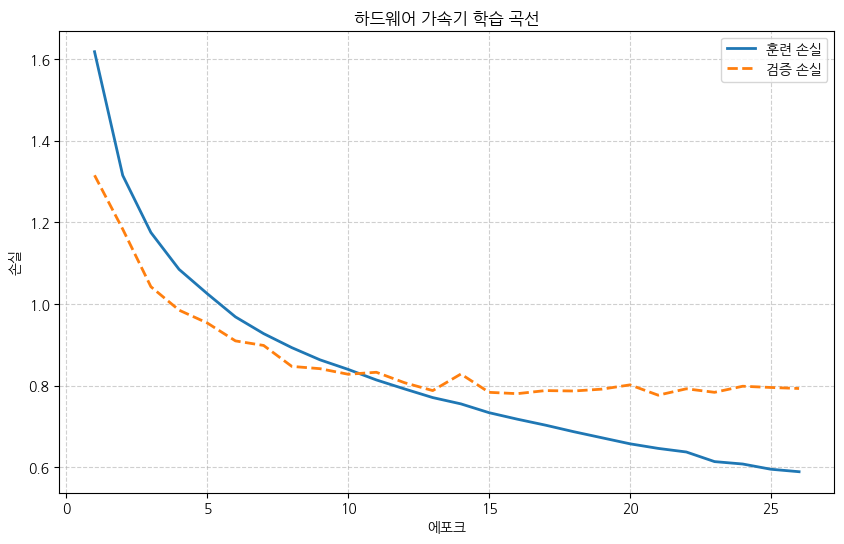

하드웨어 가속기에서의 평가 정확도: 73.45%


In [19]:
# 참고 - 하드웨어 가속기를 확용해 모델 학습
# 모델과 텐서를 하드웨어 가속기로 이동하는 과정은 학습 함수에 구현되어 있음

# 모델을 생성한 후 옵티마이저 생성 전에 장치로 이동
model = CIFAR10ConvClassifier()
#model.to(device)                                # 모델 - 할당 연산 미사용

# 하이퍼파라미터, 옵티마이저, 손실 함수 생성
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 모델 학습 - 장치 객체를 인자로 전달
log_gpu = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_gpu.plot(title='하드웨어 가속기 학습 곡선', y_label='손실')
acc_test_gpu, _, _ = common.get_accuracy(model, test_loader, device)
print(f'하드웨어 가속기에서의 평가 정확도: {acc_test_gpu:.2f}%')

- 시각화나 넘파이 변환처럼 CPU에서 해야 하는 작업을 위해 텐서를 되돌린다.

In [20]:
######################################################################################
# 코드 5-19 - 모델과 텐서를 CPU로 되돌리기
######################################################################################

# 모델을 CPU로 이동: 모델과 텐서의 위치가 다르면 같은 위치로 이동시켜야 함
#   torch.device('cpu') 대신 'cpu'로도 지정 가능
model.to('cpu')

# 모델을 사용해 예측(CPU 에서 실행)
model.eval()
with torch.no_grad():
    sample_img, _ = test_set[0]                     # (3, 32, 32) 형태의 샘플
    output = model(sample_img.unsqueeze(0))         # (1, 10) 형태의 출력
    predicted = output.argmax(dim=1).item()
    print(f'예측 클래스: {predicted} ({class_names[predicted]})')
# 또는 모델 대신 텐서를 하드웨어 가속기 장치로 이동시켜 예측해야 함

예측 클래스: 3 (cat)


In [21]:
# 참고 - to() 메서드가 받는 인자

# 텐서의 to() 메서드: 인자의 형태에 따라 바꿀 속성을 결정
t = torch.tensor([1., 2.])
print('원래의 텐서:', t)
print('float64형으로 변경:', t.to(torch.double))        # 자료형인 경우: 자료형만 변경
print('장채 객체 지정해 장치 변경:', t.to(device))      # 문자열 또는 장치 객에인 경우: 장치만 변경
print('문자열로 지정해 장치 변경:', t.to('cuda'))       # CUDA 사용 여부에 따라 예외 발생할 수 있음
# 둘다 바꿀 수도 있음
print('자료형, 장치 동시에 변경:', t.to(device, torch.double))
# 다만 둘 다 지정할 때는 장치 - 자료형 순서로 지정해야 함
# print(t.to(torch.double, device))     # TypeError 예외 발생
# 또는 키워드 인자로 지정
print('키워드 인자로 자료형, 장치 동시에 변경:', t.to(dtype=torch.double, device=device))

원래의 텐서: tensor([1., 2.])
float64형으로 변경: tensor([1., 2.], dtype=torch.float64)
장채 객체 지정해 장치 변경: 

tensor([1., 2.], device='cuda:0')
문자열로 지정해 장치 변경: tensor([1., 2.], device='cuda:0')
자료형, 장치 동시에 변경: tensor([1., 2.], device='cuda:0', dtype=torch.float64)
키워드 인자로 자료형, 장치 동시에 변경: tensor([1., 2.], device='cuda:0', dtype=torch.float64)


## 정리

- CIFAR-10은 3채널 컬러 이미지라 MNIST보다 난도가 높고, 같은 구조로도 과적합이 쉽게 나타난다.
- 데이터 증강은 훈련 데이터셋에만 적용해 다양성을 늘리고, 드롭아웃은 특정 뉴런에 대한 의존을 줄인다. 두 방법 모두 일반화 성능을 높인다.
- 모델과 텐서는 같은 장치에 있어야 하며, `to()` 메서드로 옮긴다. 시각화나 넘파이 변환 전에는 CPU로 되돌려야 한다.

> 학습 결과의 구체적인 수치는 실행 환경에 따라 본문과 조금씩 다를 수 있다.